In [ ]:
# for huge datasets, if there is numerical data u can use either k means or hierarchical

# steps :
# initialize k centroids
# points that are nearest to the centroids-group them 
# move the centroid by calculating the mean of the data points
# repeat the above 2 steps until the centroids do not change

# how to calculate value of k 
# WCSS (within cluster sum of squares) = sum of squared distance between each point and its centroid
# Elbow method - plot WCSS vs k and find the elbow point where the WCSS starts to decrease at a slower rate

# use intilization method to select initial centroids - kmeans++ (it makes sures that centroides are intialzed far away from each other)
# k represents the exact number of clusters or groups you want the algorithm to divide your dataset into.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

%matplotlib inline

In [3]:
X, y = make_blobs(n_samples=1000, centers=3, n_features=2, random_state=23)

#here we are only interested in indepencdent variables , therefore we will not use y in our model building

In [4]:
X.shape

(1000, 2)

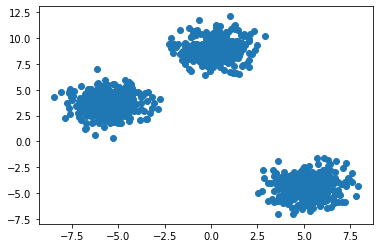

In [5]:
plt.scatter(X[:,0], X[:,1])

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)


##### To find k

In [ ]:
from sklearn.cluster import KMeans

# manual method- elbow method to select k value

wcss =[]

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++')
    kmeans.fit(X_train)
    wcss.append(kmeans.inertia_)

wcss

c:\ProgramData\Anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1440: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\ProgramData\Anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1440: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\ProgramData\Anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1440: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\ProgramData\Anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1440: UserWarning: KMeans is known to have a memory leak on Window

[34827.57682552021,
 7935.4372861454185,
 1319.2730531585605,
 1140.4677884655127,
 991.8238694516631,
 854.2929980760774,
 754.3818382775476,
 663.7009456137093,
 579.4942337478147,
 531.3846583938488]

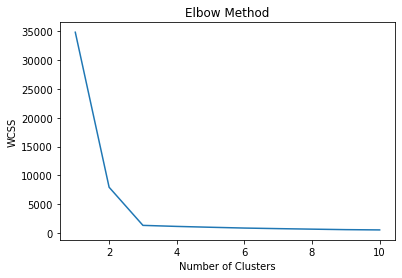

In [9]:
#plot elbow curve
plt.plot(range(1, 11), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [15]:
# knee locator
from kneed import KneeLocator
kl = KneeLocator(range(1, 11), wcss, curve='convex', direction='decreasing')

kl.elbow

3

##### main code

c:\ProgramData\Anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\ProgramData\Anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1440: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


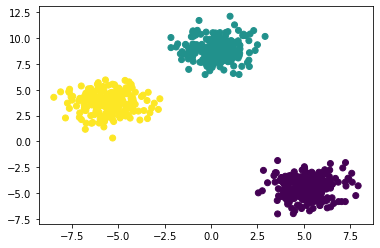

In [ ]:
#this shows that the elbow point is at k=3, therefore we will use k=3 for our model building

kmeans = KMeans(n_clusters=3, init='k-means++')
y_labels = kmeans.fit_predict(X_train)

#y_labels is basically a name for the cluster

plt.scatter(X_train[:,0], X_train[:,1], c=y_labels)



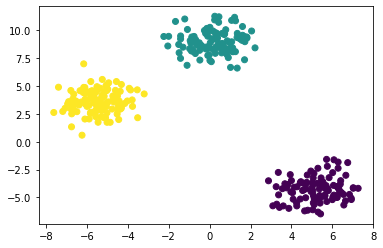

In [13]:
y_test_labels = kmeans.predict(X_test)

plt.scatter(X_test[:,0], X_test[:,1], c=y_test_labels)


c:\ProgramData\Anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\ProgramData\Anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1440: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\ProgramData\Anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\ProgramData\Anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1440: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are

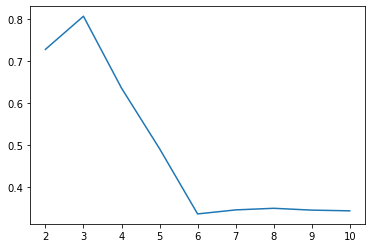

In [17]:
from sklearn.metrics import silhouette_score
silhouette_coefficient = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++')
    kmeans.fit(X_train)
    score = silhouette_score(X_train, kmeans.labels_)
    silhouette_coefficient.append(score)

silhouette_coefficient

plt.plot(range(2, 11), silhouette_coefficient)